# Importing the necessary libraries

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif, mutual_info_regression,f_regression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier ,GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb

# loading the file plus feature engineering

In [28]:
# ------------------------------
# 1. Load Data, Drop COVID Anomaly & Engineer Targets
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# Drop COVID anomaly year only (keep 2026 — used as test boundary)
df = df[df['Year'] != 2021].reset_index(drop=True)

repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)
overage_cols = ["pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec"]
df["over_age_enrollment_total"]=df[overage_cols].sum(axis = 1)
# avg_promotion_rate removed — unused downstream


In [29]:
# ------------------------------
# 2. Staff Qualification Feature Engineering
# ------------------------------
edu_levels = ["primary", "lower_sec", "upper_sec", "graduate", "postgrad", "phd"]
weights = {"primary": 1, "lower_sec": 2, "upper_sec": 3, "graduate": 4, "postgrad": 5, "phd": 6}

# No-pedagogy ratio
df["no_pedagogy_ratio"] = (
    df[[f"teaching_staff_no_pedagogy_{l}" for l in edu_levels]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# High/low qual ratio (teaching staff)
df["teaching_high_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["graduate", "postgrad", "phd"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)
df["teaching_low_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["primary", "lower_sec", "upper_sec"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# Qualification index per staff group
for prefix in ["teaching_staff_edu", "non_teaching_staff_edu", "teaching_staff_no_pedagogy"]:
    weighted_sum = sum(df[f"{prefix}_{level}"] * w for level, w in weights.items())
    total = df[[f"{prefix}_{level}" for level in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f"{prefix}_qual_index"] = weighted_sum / total


In [30]:
print(df.shape)
print(df[['Year','enrollment_total']].groupby('Year').mean())

(250, 272)
      enrollment_total
Year                  
2016         120385.44
2017         123106.40
2018         125730.08
2019         127566.88
2020         128411.40
2022         130631.08
2023         133770.48
2024         136326.16
2025         136928.20
2026         128292.92


count       250.000000
mean     129114.904000
std       84816.406568
min        8162.000000
25%       51697.000000
50%      123149.500000
75%      206739.750000
max      285422.000000
Name: enrollment_total, dtype: float64
Axes(0.125,0.11;0.775x0.77)


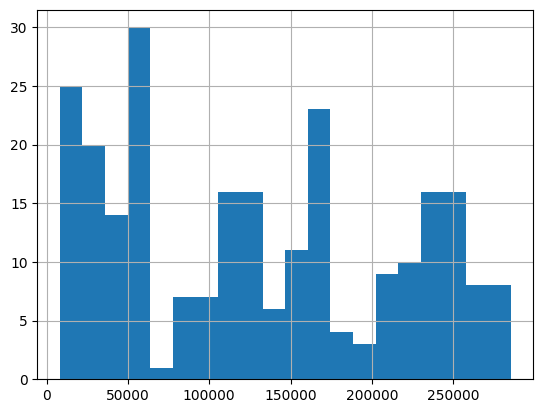

In [31]:
print(df['enrollment_total'].describe())
print(df['enrollment_total'].hist(bins=20))

In [32]:
print(df.shape)
print(df[['Year','avg_dropout_rate']].groupby('Year').mean())

(250, 272)
      avg_dropout_rate
Year                  
2016         14.182333
2017         11.764667
2018         10.903143
2019         10.799647
2020         13.246976
2022         13.512436
2023         12.585495
2024         10.700333
2025          9.753000
2026          9.171333


count    250.000000
mean      11.661936
std        2.535054
min        6.491667
25%        9.827083
50%       11.454167
75%       13.250640
max       21.433333
Name: avg_dropout_rate, dtype: float64
Axes(0.125,0.11;0.775x0.77)


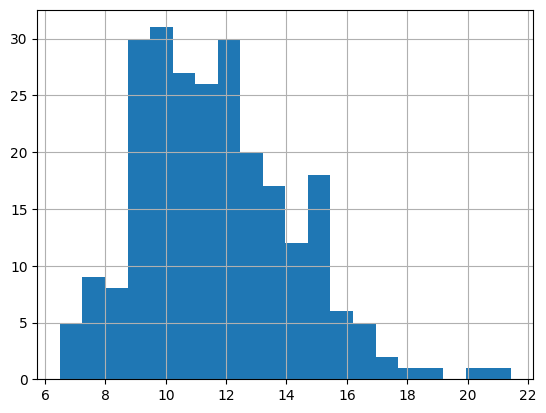

In [33]:
print(df['avg_dropout_rate'].describe())
print(df['avg_dropout_rate'].hist(bins=20))

In [34]:
print(df.shape)
print(df[['Year','teaching_staff_edu_qual_index']].groupby('Year').mean())

(250, 272)
      teaching_staff_edu_qual_index
Year                               
2016                       2.886743
2017                       2.935811
2018                       2.960639
2019                       3.010407
2020                       3.017466
2022                       3.099015
2023                       3.158603
2024                       3.189569
2025                       3.211495
2026                       3.285969


count    250.000000
mean       3.075572
std        0.205065
min        2.424284
25%        2.947118
50%        3.089394
75%        3.225114
max        3.523707
Name: teaching_staff_edu_qual_index, dtype: float64
Axes(0.125,0.11;0.775x0.77)


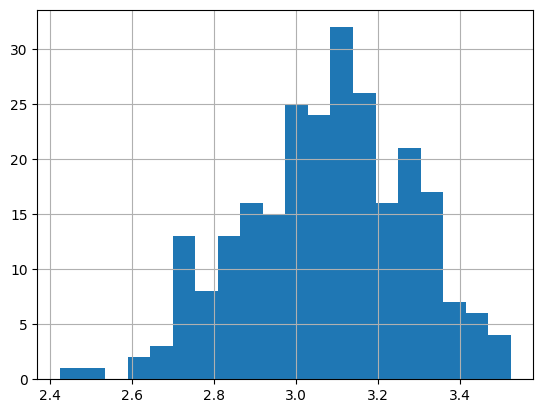

In [35]:
print(df['teaching_staff_edu_qual_index'].describe())
print(df['teaching_staff_edu_qual_index'].hist(bins=20))

# feature selection and model training

In [36]:

features_for_enrollment = [
    "num_schools", "classes_in_pagoda", "repeaters_total", "total_staff_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee",
    "schools_without_water", "schools_without_latrine", "principal_avg_age", "principal_avg_service_years",
    "principal_upper_sec_plus_edu", "principal_female", "num_primary_schools", "num_cluster_schools",
    "satellite_schools", "num_buildings_total", "num_rooms_total", "concrete_brick_buildings",
    "wooden_buildings", "bamboo_buildings", "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall", "schools_with_office",
    "schools_with_library", "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "preschool_with_sport_facility", "sport_volleyball", "sport_football", "sport_basketball",
    "sport_climbing_ropes", "sport_shotput", "sport_high_jump", "sport_long_jump", "sport_running",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel", "funding_school_income", "funding_community",
    "funding_govt_building", "funding_abroad", "funding_ios_ngos", "pupils_per_school", "teachers_per_school",
    "staff_per_school", "buildings_per_school", "rooms_per_school", "classrooms_per_school",
    "classes_per_school", "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio",
    "pupil_classroom_ratio", "classes_per_classroom", "classroom_area_per_pupil_m2", "gross_admission_rate_total",
    "net_admission_rate_total", "pct_overage_admission_total", "transition_rate_lower_sec_total",
    "transition_rate_upper_sec_total",
    "no_pedagogy_ratio", "teaching_high_qual_ratio",
    "teaching_low_qual_ratio", "teaching_staff_edu_qual_index",
    "non_teaching_staff_edu_qual_index", "teaching_staff_no_pedagogy_qual_index"
]
features_for_dropout = [
    "num_schools", "classes_in_pagoda","repeaters_total","total_staff_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee","schools_without_water", "schools_without_latrine",
    "principal_avg_age", "principal_avg_service_years", "principal_upper_sec_plus_edu", "principal_female",
    "num_primary_schools", "num_cluster_schools", "satellite_schools",
    "num_buildings_total", "num_rooms_total",
    "concrete_brick_buildings","wooden_buildings","bamboo_buildings",
    "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall","over_age_enrollment_total",
    "schools_with_office", "schools_with_library",
    "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel",
    "funding_school_income", "funding_community", "funding_govt_building", "funding_abroad", "funding_ios_ngos",
    "pupils_per_school", "teachers_per_school", "staff_per_school",
    "buildings_per_school", "rooms_per_school", "classrooms_per_school", "classes_per_school",
    "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio", "pupil_classroom_ratio",
    "classes_per_classroom", "classroom_area_per_pupil_m2",
    "gross_admission_rate_total","net_admission_rate_total","transition_rate_lower_sec_total","transition_rate_upper_sec_total",
    "no_pedagogy_ratio", "teaching_high_qual_ratio",
    "teaching_low_qual_ratio", "teaching_staff_edu_qual_index",
    "non_teaching_staff_edu_qual_index", "teaching_staff_no_pedagogy_qual_index"
]
features_for_teacher = [
    "num_schools", "classes_in_pagoda", "repeaters_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee",
    "schools_without_water", "schools_without_latrine", "principal_avg_age", "principal_avg_service_years",
    "principal_upper_sec_plus_edu", "principal_female", "num_primary_schools", "num_cluster_schools",
    "satellite_schools", "num_buildings_total", "num_rooms_total", "concrete_brick_buildings",
    "wooden_buildings", "bamboo_buildings", "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall", "schools_with_office",
    "schools_with_library", "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "preschool_with_sport_facility", "sport_volleyball", "sport_football", "sport_basketball",
    "sport_climbing_ropes", "sport_shotput", "sport_high_jump", "sport_long_jump", "sport_running",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel", "funding_school_income", "funding_community",
    "funding_govt_building", "funding_abroad", "funding_ios_ngos", "pupils_per_school", "teachers_per_school",
    "staff_per_school", "buildings_per_school", "rooms_per_school", "classrooms_per_school",
    "classes_per_school", "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio",
    "pupil_classroom_ratio", "classes_per_classroom", "classroom_area_per_pupil_m2", "gross_admission_rate_total",
    "net_admission_rate_total", "pct_overage_admission_total", "transition_rate_lower_sec_total",
    "transition_rate_upper_sec_total", "avg_repetition_rate", "avg_dropout_rate",
]

In [37]:
def select_features(df, target_col, features_all, k_num=10, classification=False, log_transform=False):
    """
    Perform 3 feature selection methods on a dataset, including union and intersection strategies.
    """
    y = df[target_col].copy()
    
    # Apply log transform BEFORE feature selection if specified
    if log_transform:
        y = np.log1p(y)  # log1p handles 0 values safely
    
    if classification:
        y = pd.qcut(y, q=3, labels=["low", "medium", "high"], duplicates='drop')

    # Only keep features that exist in the dataframe
    valid_features = [f for f in features_all if f in df.columns]
    X = df[valid_features].copy()

    # FIX: impute before any sklearn method
    X = X.fillna(np.nan)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    results = {}

    # Method 1: ANOVA F-test
    score_fn_anova = f_classif if classification else f_regression
    anova_sel = SelectKBest(score_func=score_fn_anova, k=k_num).fit(X_imp, y)
    results['anova'] = list(X_imp.columns[anova_sel.get_support()])

    # Method 2: Mutual Information
    mi_fn = mutual_info_classif if classification else mutual_info_regression
    mi_sel = SelectKBest(score_func=mi_fn, k=k_num).fit(X_imp, y)
    results['mutual_info'] = list(X_imp.columns[mi_sel.get_support()])

    # Method 3: RFE
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1) if classification else RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe_sel = RFE(estimator=estimator, n_features_to_select=k_num, step=2)
    rfe_sel.fit(X_imp, y)
    results['rfe'] = list(X_imp.columns[rfe_sel.support_])

    # STRATEGY: Intersection
    common = sorted(set(results['anova']) & set(results['mutual_info']) & set(results['rfe']))
    results['common_features'] = common

    # STRATEGY: Union
    union = sorted(set(results['anova']) | set(results['mutual_info']) | set(results['rfe']))
    results['union_features'] = union
    
    results['X_pure'] = X_imp
    results['y'] = y

    return results
    """
    Perform 3 feature selection methods on a dataset, including union and intersection strategies.
    """
    y = df[target_col].copy()
    if classification:
        y = pd.qcut(y, q=3, labels=["low", "medium", "high"], duplicates='drop')

    # Only keep features that exist in the dataframe
    valid_features = [f for f in features_all if f in df.columns]
    X = df[valid_features].copy()

    # FIX: impute before any sklearn method — all 3 fail on NaN
    X = X.fillna(np.nan)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    results = {}

    # Method 1: ANOVA F-test (FIXED: Uses f_regression if classification=False)
    score_fn_anova = f_classif if classification else f_regression
    anova_sel = SelectKBest(score_func=score_fn_anova, k=k_num).fit(X_imp, y)
    results['anova'] = list(X_imp.columns[anova_sel.get_support()])

    # Method 2: Mutual Information
    mi_fn = mutual_info_classif if classification else mutual_info_regression
    mi_sel = SelectKBest(score_func=mi_fn, k=k_num).fit(X_imp, y)
    results['mutual_info'] = list(X_imp.columns[mi_sel.get_support()])

    # Method 3: RFE
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1) if classification else RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe_sel = RFE(estimator=estimator, n_features_to_select=k_num, step=2)
    rfe_sel.fit(X_imp, y)
    results['rfe'] = list(X_imp.columns[rfe_sel.support_])

    # STRATEGY: Intersection (Common features)
    common = sorted(set(results['anova']) & set(results['mutual_info']) & set(results['rfe']))
    results['common_features'] = common

    # STRATEGY: Union (Combined unique features from all methods)
    union = sorted(set(results['anova']) | set(results['mutual_info']) | set(results['rfe']))
    results['union_features'] = union
    
    results['X_pure'] = X_imp
    results['y'] = y

    return results


# ------------------------------
# 5. Tournament Strategy Function
# ------------------------------
def run_feature_tournament(fs_results, classification=False):
    """
    Evaluates all feature subsets via cross-validation to find the highest performing group.
    """
    X = fs_results['X_pure']
    y = fs_results['y']
    
    # Define tournament subsets
    subsets = {
        'ANOVA Subset': fs_results['anova'],
        'Mutual Info Subset': fs_results['mutual_info'],
        'RFE Subset': fs_results['rfe'],
        'Union Strategy (Combined All Unique)': fs_results['union_features'],
        'Intersection Strategy (Common Only)': fs_results['common_features']
    }
    
    # Pick baseline evaluator model based on task type
    model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
    metric = 'accuracy' if classification else 'r2'
    
    print(f"--- Running Feature Tournament (Metric: {metric.upper()}) ---")
    
    tournament_scores = {}
    for name, features in subsets.items():
        if len(features) == 0:
            print(f"🏆 {name}: No features selected. Skipping.")
            continue
            
        # Evaluate subset performance with 5-fold cross-validation
        scores = cross_val_score(model, X[features], y, cv=5, scoring=metric)
        avg_score = np.mean(scores)
        tournament_scores[name] = avg_score
        print(f"⭐ {name} ({len(features)} features) -> Score: {avg_score:.4f}")
        
    winner = max(tournament_scores, key=tournament_scores.get)
    print(f"\n🥇 TOURNAMENT WINNER: {winner} with a score of {tournament_scores[winner]:.4f}")
    return subsets[winner]


# Execution
results = select_features(
    df=df,
    target_col="enrollment_total",
    features_all=features_for_enrollment,
    k_num=10,
    classification=False,
    log_transform=False  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_14780\3212007768.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(np.nan)


ANOVA top features:       ['num_schools', 'repeaters_total', 'total_staff_total', 'two_shift_schools_lycee', 'attached_preschool_lycee', 'num_primary_schools', 'num_cluster_schools', 'satellite_schools', 'num_buildings_total', 'concrete_brick_buildings']
Mutual Info top features: ['num_schools', 'total_staff_total', 'two_shift_schools_lycee', 'attached_preschool_lycee', 'num_primary_schools', 'num_cluster_schools', 'satellite_schools', 'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings']
RFE top features:         ['repeaters_total', 'total_staff_total', 'two_shift_schools_lycee', 'principal_female', 'num_primary_schools', 'satellite_schools', 'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings', 'pupil_teacher_ratio']
Union Strategy features:  ['attached_preschool_lycee', 'concrete_brick_buildings', 'num_buildings_total', 'num_cluster_schools', 'num_primary_schools', 'num_rooms_total', 'num_schools', 'principal_female', 'pupil_teacher_ratio', 'repeaters

In [38]:
# --- Run for avg_dropout_rate ---
results = select_features(
    df=df,
    target_col="avg_dropout_rate",
    features_all=features_for_dropout,
    k_num=10,
    classification=False,
    log_transform=True  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_14780\3212007768.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(np.nan)


ANOVA top features:       ['over_age_enrollment_total', 'buildings_per_school', 'classrooms_per_school', 'classes_per_classroom', 'transition_rate_lower_sec_total', 'transition_rate_upper_sec_total', 'teaching_high_qual_ratio', 'teaching_low_qual_ratio', 'teaching_staff_edu_qual_index', 'non_teaching_staff_edu_qual_index']
Mutual Info top features: ['principal_avg_age', 'principal_avg_service_years', 'satellite_schools', 'over_age_enrollment_total', 'pb_fund_per_school_riel', 'buildings_per_school', 'rooms_per_school', 'classes_per_school', 'classes_per_classroom', 'transition_rate_lower_sec_total']
RFE top features:         ['schools_without_water', 'over_age_enrollment_total', 'pb_fund_per_school_riel', 'funding_abroad', 'staff_per_school', 'buildings_per_school', 'gross_admission_rate_total', 'transition_rate_lower_sec_total', 'transition_rate_upper_sec_total', 'teaching_staff_edu_qual_index']
Union Strategy features:  ['buildings_per_school', 'classes_per_classroom', 'classes_per_s

In [39]:
results = select_features(
    df=df,
    target_col="teaching_staff_edu_qual_index",
    features_all=features_for_teacher,
    k_num=10,
    classification=False,
    log_transform=False  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

ANOVA top features:       ['principal_avg_service_years', 'buildings_poor_floor', 'sport_basketball', 'buildings_per_school', 'classrooms_per_school', 'pupil_class_ratio', 'classes_per_classroom', 'gross_admission_rate_total', 'pct_overage_admission_total', 'transition_rate_lower_sec_total']
Mutual Info top features: ['schools_without_latrine', 'principal_avg_service_years', 'principal_upper_sec_plus_edu', 'num_buildings_total', 'buildings_poor_floor', 'buildings_poor_roof', 'sport_football', 'pb_fund_per_student_riel', 'pb_fund_per_school_riel', 'classrooms_per_school']
RFE top features:         ['schools_without_latrine', 'principal_avg_service_years', 'principal_upper_sec_plus_edu', 'buildings_poor_roof', 'schools_with_office', 'pb_fund_per_student_riel', 'pb_fund_per_school_riel', 'classrooms_per_school', 'gross_admission_rate_total', 'transition_rate_lower_sec_total']
Union Strategy features:  ['buildings_per_school', 'buildings_poor_floor', 'buildings_poor_roof', 'classes_per_cla

>>> ENROLLMENT

  TARGET: enrollment_total
            Model      R²       RMSE        MAE
          XGBoost  0.9914  8009.9168  5517.7021
Gradient Boosting  0.9908  8296.6871  5319.8609
            Lasso  0.9901  8595.1884  6447.2609
            Ridge  0.9901  8595.8679  6446.5717
    Random Forest  0.9837 11005.9662  7292.3462
     SVR (Linear) -0.0069 86630.4825 73917.2229
        SVR (RBF) -0.0218 87265.2053 74436.2853



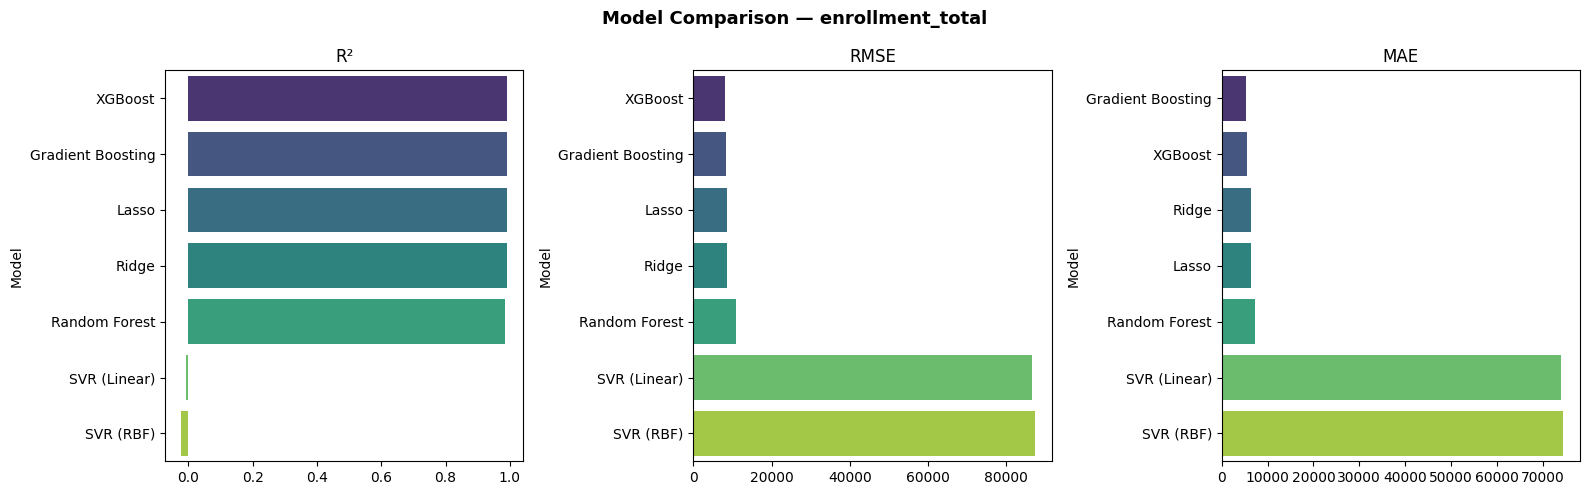

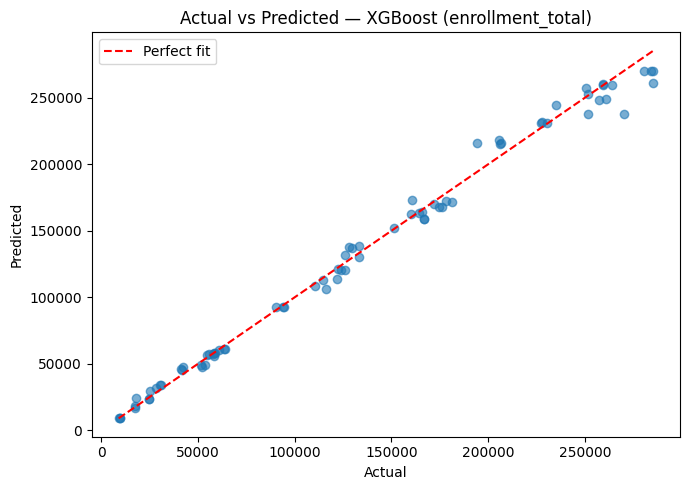

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
            Model      R²   RMSE    MAE
    Random Forest -0.5200 2.1627 1.8641
            Lasso -0.5800 2.2050 1.8589
            Ridge -0.6606 2.2606 1.7801
     SVR (Linear) -0.7389 2.3132 1.8301
          XGBoost -0.8965 2.4158 2.0950
Gradient Boosting -1.1134 2.5502 2.1790
        SVR (RBF) -4.2247 4.0097 3.4619



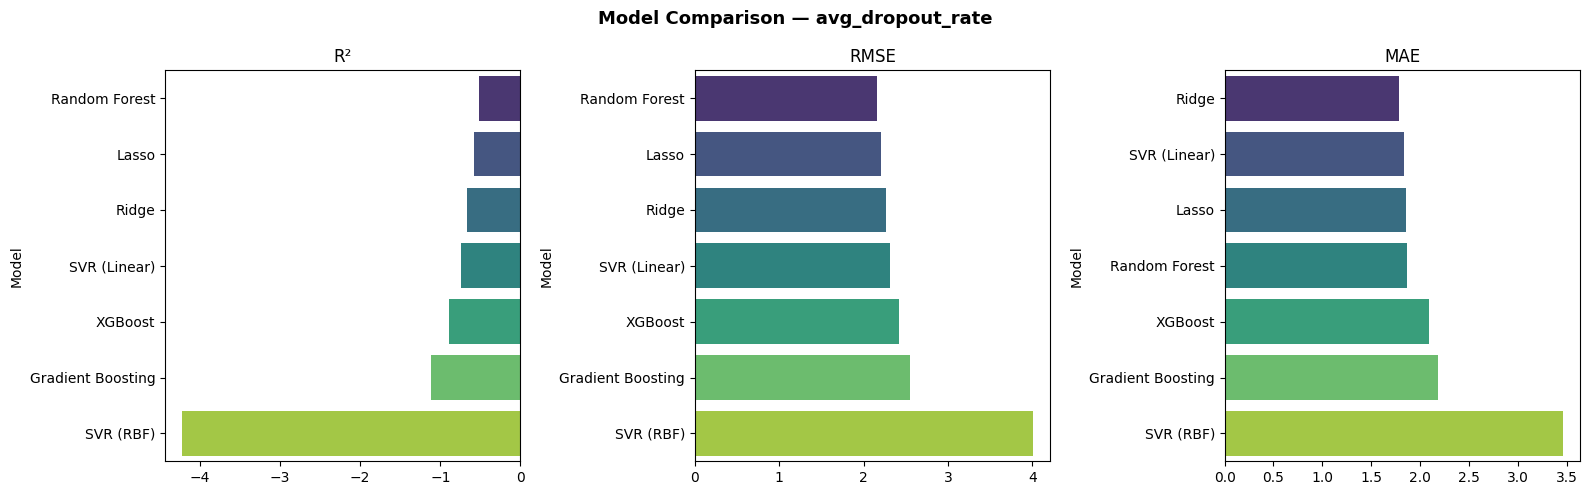

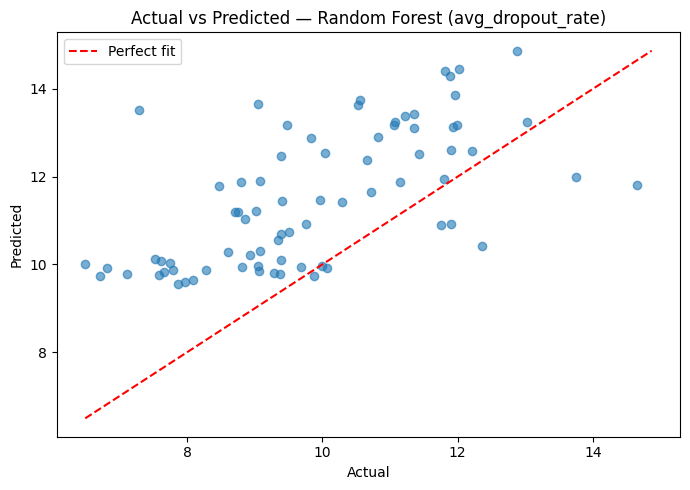

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
            Model      R²   RMSE    MAE
Gradient Boosting  0.5385 0.1104 0.0860
          XGBoost  0.4869 0.1164 0.0910
    Random Forest  0.3921 0.1267 0.1009
        SVR (RBF)  0.3369 0.1323 0.1025
            Lasso -0.1747 0.1761 0.1349
     SVR (Linear) -0.1984 0.1778 0.1374
            Ridge -0.2263 0.1799 0.1394



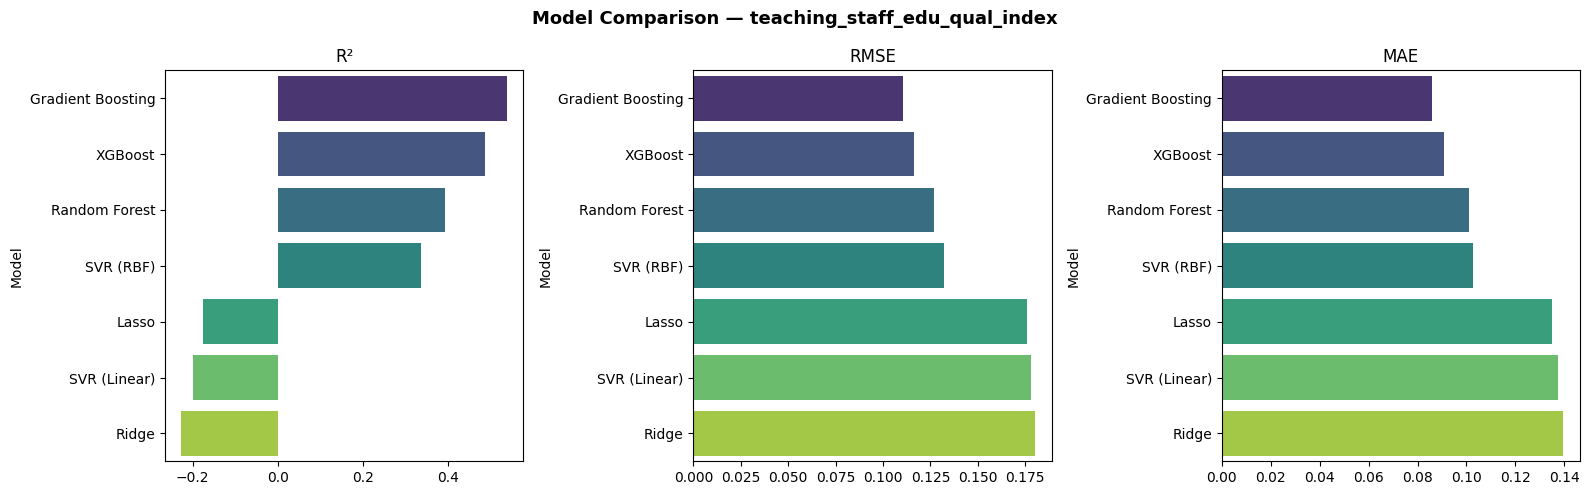

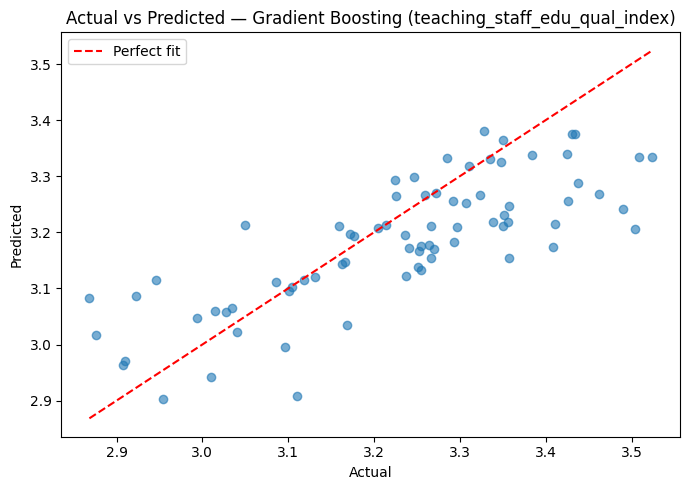

In [40]:

def forecast_compare(df, target, features, train_years=(2016, 2023), test_years=(2024, 2026), log_transform=False):
    """
    Trains multiple models on a time-split, compares MSE/R²/MAE, plots results.
    log_transform=True for skewed ratio targets like dropout rate.
    """

    # --- Prep ---
    feats = [c for c in features if c in df.columns]
    X_raw = df[feats].copy().fillna(np.nan)
    y_raw = df[target].copy()

    train_mask = df['Year'].between(*train_years)
    test_mask  = df['Year'].between(*test_years)

    X_train, X_test = X_raw[train_mask], X_raw[test_mask]
    y_train, y_test = y_raw[train_mask], y_raw[test_mask]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feats)
    X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feats)

    # Scale for SVR
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc  = scaler.transform(X_test_imp)

    if log_transform:
        y_train_fit = np.log1p(y_train.values)
    else:
        y_train_fit = y_train.values

    # --- Models ---
    models = {
        'Random Forest':       (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1),  X_train_imp, X_test_imp),
        'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),          X_train_imp, X_test_imp),
        'XGBoost':             (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),      X_train_imp, X_test_imp),
        'SVR (RBF)':           (SVR(kernel='rbf', C=10, epsilon=0.1),                                                                   X_train_sc,  X_test_sc),
        'SVR (Linear)':        (SVR(kernel='linear', C=1),                                                                              X_train_sc,  X_test_sc),
        'Ridge':               (Ridge(alpha=1.0),                                                                                       X_train_imp, X_test_imp),
        'Lasso':               (Lasso(alpha=0.01, max_iter=5000),                                                                       X_train_imp, X_test_imp),
    }

    # --- Evaluate ---
    records = []
    predictions = {}

    for name, (model, X_tr, X_te) in models.items():
        model.fit(X_tr, y_train_fit)
        y_pred_raw = model.predict(X_te)

        # reverse log if needed
        y_pred = np.expm1(y_pred_raw) if log_transform else y_pred_raw
        y_true = y_test.values

        records.append({
            'Model': name,
            'R²':    round(r2_score(y_true, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        })
        predictions[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R²', ascending=False).reset_index(drop=True)

    # --- Print table ---
    print(f"\n{'='*55}")
    print(f"  TARGET: {target}")
    print(f"{'='*55}")
    print(results_df.to_string(index=False))
    print(f"{'='*55}\n")

    # --- Plot 1: metric comparison bar chart ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
        sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
        sns.barplot(data=sorted_df, x=metric, y='Model', ax=ax,
                    hue='Model', palette='viridis', legend=False)
        ax.set_title(metric)
        ax.set_xlabel('')
    fig.suptitle(f'Model Comparison — {target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: actual vs predicted for best model ---
    best_model_name = results_df.iloc[0]['Model']
    y_best = predictions[best_model_name]

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test.values, y_best, alpha=0.6)
    lims = [min(y_test.min(), y_best.min()), max(y_test.max(), y_best.max())]
    plt.plot(lims, lims, 'r--', label='Perfect fit')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {best_model_name} ({target})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df, predictions


# ==============================
# Run all 3 models
# ==============================

features_enrollment = ['repeaters_total', 'total_staff_total', 'two_shift_schools_lycee',
                        'principal_female', 'num_primary_schools', 'satellite_schools',
                        'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings',
                        'pupil_teacher_ratio']

features_dropout = ['principal_avg_age', 'principal_avg_service_years',
                    'pct_overage_enrollment_upper_sec', 'sport_volleyball', 'sport_long_jump',
                    'pb_fund_per_school_riel', 'buildings_per_school', 'classes_per_classroom',
                    'pct_overage_admission_total', 'transition_rate_lower_sec_total']

features_teacher = ['schools_without_water', 'schools_without_latrine', 'principal_avg_service_years',
                    'principal_upper_sec_plus_edu', 'buildings_poor_roof', 'pb_fund_per_student_riel',
                    'pb_fund_per_school_riel', 'classrooms_per_school',
                    'gross_admission_rate_total', 'transition_rate_lower_sec_total']

print(">>> ENROLLMENT")
res_enrollment, pred_enrollment = forecast_compare(
    df, target='enrollment_total', features=features_enrollment, log_transform=False)

print(">>> DROPOUT RATE")
res_dropout, pred_dropout = forecast_compare(
    df, target='avg_dropout_rate', features=features_dropout, log_transform=True)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_compare(
    df, target='teaching_staff_edu_qual_index', features=features_teacher, log_transform=False)

In [41]:
print ( "hi ramorn")

hi ramorn


In [42]:
print("Hi Laisrun")

Hi Laisrun
